# 03 — Baseline Hierarchical U-Net LOSO Training

This notebook trains the first clean Dataset V2 baseline:

**Dataset V2 → LOSO folds → 6-channel thermal input → body head + cold head → validation threshold selection → held-out test subject evaluation.**

Leakage rules: test subject is never used in training; validation subject is used only for threshold/model selection; no GenAI is used here yet.

In [1]:
# ============================================================
# SECTION 00 — IMPORTS + CONFIG
# ============================================================

from pathlib import Path
import json, re, math, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from scipy import ndimage as ndi
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

EPOCHS = 80
BATCH_SIZE = 4
NUM_WORKERS = 2
LR = 3e-4
WEIGHT_DECAY = 1e-5
BASE_CH = 16
USE_AMP = True

BODY_BCE_W = 1.0
BODY_DICE_W = 1.0
COLD_BCE_W = 0.5
COLD_DICE_W = 1.0
COLD_TVERSKY_W = 1.0
OUTSIDE_BODY_W = 0.3
AREA_RATIO_W = 0.10

BODY_THRS = [0.30, 0.40, 0.50, 0.60]
COLD_THRS = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60]
MIN_COLD_CC_LIST = [0, 20, 50]

RUN_ALL_FOLDS = True
SAVE_QUALITATIVE_EVERY_FOLD = True
MAX_QUALITATIVE_PER_FOLD = 8

print("Ready.")

Using device: cuda:0
GPU name: Tesla V100-PCIE-32GB
Ready.


In [2]:
# ============================================================
# SECTION 01 — LOCATE DATASET V2 + LOSO SPLITS
# ============================================================

PREP_DIR = None
SPLIT_DIR = None

# Optional manual paths:
# PREP_DIR = Path("/media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_prepared")
# SPLIT_DIR = Path("/media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_splits")

if PREP_DIR is None:
    search_roots = [Path.cwd(), Path("/media/data/rPPG/rPPG_Data/SHARE/PixelLabelData"), Path("/mnt/data")]
    found = []
    for root in search_roots:
        if root.exists():
            found.extend(list(root.rglob("training_manifest_v2.csv")))
    if len(found) == 0:
        raise FileNotFoundError("Could not find training_manifest_v2.csv. Set PREP_DIR manually.")
    found = sorted(found, key=lambda p: str(p))
    PREP_DIR = found[0].parent

TRAIN_MANIFEST_PATH = PREP_DIR / "training_manifest_v2.csv"
MANIFEST_PATH = PREP_DIR / "manifest_v2.csv"

if SPLIT_DIR is None:
    candidate = PREP_DIR.parent / "dataset_v2_splits"
    if candidate.exists():
        SPLIT_DIR = candidate
    else:
        found = []
        for root in [PREP_DIR.parent, Path.cwd(), Path("/mnt/data")]:
            if root.exists():
                found.extend(list(root.rglob("loso_split_summary.csv")))
        if len(found) == 0:
            SPLIT_DIR = PREP_DIR.parent / "dataset_v2_splits"
            SPLIT_DIR.mkdir(parents=True, exist_ok=True)
        else:
            SPLIT_DIR = sorted(found, key=lambda p: str(p))[0].parent

RUN_ROOT = PREP_DIR.parent / "runs_baseline_hierunet_v2_loso"
RUN_ROOT.mkdir(parents=True, exist_ok=True)

print("PREP_DIR:", PREP_DIR)
print("TRAIN_MANIFEST_PATH:", TRAIN_MANIFEST_PATH)
print("SPLIT_DIR:", SPLIT_DIR)
print("RUN_ROOT:", RUN_ROOT)

PREP_DIR: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_prepared
TRAIN_MANIFEST_PATH: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_prepared/training_manifest_v2.csv
SPLIT_DIR: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_splits
RUN_ROOT: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/runs_baseline_hierunet_v2_loso


In [3]:
# ============================================================
# SECTION 02 — LOAD MANIFEST + FOLD PLAN
# ============================================================

df = pd.read_csv(TRAIN_MANIFEST_PATH)
required = ["sample_id", "subject_id", "prepared_image_npy", "body_mask_path", "cold_mask_path"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in training_manifest_v2.csv: {missing}")

df["image_path"] = df["prepared_image_npy"].astype(str)
df["body_path"] = df["body_mask_path"].astype(str)
df["cold_path"] = df["cold_mask_path"].astype(str)
df["subject_id"] = df["subject_id"].astype(str)
df["sample_id"] = df["sample_id"].astype(str)
if "doctor_group" not in df.columns:
    df["doctor_group"] = "UNK"
if "repeat_id" not in df.columns:
    df["repeat_id"] = -1

print("Loaded training manifest:", df.shape)
display(df.head())

split_summary_path = SPLIT_DIR / "loso_split_summary.csv"
if split_summary_path.exists():
    fold_plan = pd.read_csv(split_summary_path)
    print("Loaded LOSO split summary:", split_summary_path)
else:
    def natkey(x):
        return re.sub(r"(\d+)", lambda m: m.group(1).zfill(8), str(x))
    subjects_tmp = sorted(df["subject_id"].unique(), key=natkey)
    rows = []
    for i, test_subject in enumerate(subjects_tmp):
        val_subject = subjects_tmp[(i + 1) % len(subjects_tmp)]
        train_subjects = [s for s in subjects_tmp if s not in [test_subject, val_subject]]
        rows.append({"fold_id": f"fold_{test_subject}", "test_subject": test_subject, "val_subject": val_subject, "train_subjects": ",".join(train_subjects)})
    fold_plan = pd.DataFrame(rows)
    fold_plan.to_csv(split_summary_path, index=False)
    print("Created LOSO split summary:", split_summary_path)

display(fold_plan)

Loaded training manifest: (78, 14)


,sample_id,subject_id,doctor_group,repeat_id,prepared_image_npy,body_mask_path,cold_mask_path,body_pixels,cold_pixels,cold_body_ratio,use_for_training,image_path,body_path,cold_path
0,S05-B-2,S05,B,2,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,29231,4079,0.139544,True,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
1,S05-B-3,S05,B,3,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,29027,2324,0.080063,True,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
2,S05-C-1,S05,C,1,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,29324,871,0.029703,True,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
3,S05-C-2,S05,C,2,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,28034,554,0.019762,True,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
4,S05-C-3,S05,C,3,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,29153,608,0.020855,True,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...


Loaded LOSO split summary: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_splits/loso_split_summary.csv


,fold_id,train_subjects,val_subject,test_subject,n_train,n_val,n_test,json_path
0,fold_S05,"S07,S08,S09,S10,S11",S06,S05,59,11,8,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
1,fold_S06,"S05,S08,S09,S10,S11",S07,S06,55,12,11,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
2,fold_S07,"S05,S06,S09,S10,S11",S08,S07,55,11,12,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
3,fold_S08,"S05,S06,S07,S10,S11",S09,S08,55,12,11,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
4,fold_S09,"S05,S06,S07,S08,S11",S10,S09,54,12,12,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
5,fold_S10,"S05,S06,S07,S08,S09",S11,S10,54,12,12,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
6,fold_S11,"S06,S07,S08,S09,S10",S05,S11,58,8,12,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...


In [4]:
# ============================================================
# SECTION 03 — IMAGE + MASK LOADING AND 6-CHANNEL INPUT CREATION
# ============================================================

def load_image_npy_or_png(path):
    path = Path(path)
    if path.suffix.lower() == ".npy":
        arr = np.load(path)
    else:
        arr = np.array(Image.open(path))
        if arr.ndim == 3:
            arr = arr[..., 0]
    return arr.astype(np.float32)


def load_binary_mask(path):
    arr = np.array(Image.open(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    return (arr > 0).astype(np.float32)


def robust_norm01(x, p_low=1, p_high=99):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p_low, p_high])
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    x = np.clip(x, lo, hi)
    return ((x - lo) / (hi - lo + 1e-8)).astype(np.float32)


def local_mean_filter(x, k=21):
    if SCIPY_AVAILABLE:
        return ndi.uniform_filter(x, size=k, mode="reflect")
    pad = k // 2
    xp = np.pad(x, pad, mode="reflect")
    out = np.zeros_like(x, dtype=np.float32)
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            out[i, j] = xp[i:i+k, j:j+k].mean()
    return out


def make_6ch_input(img):
    # No GT mask is used. All channels are image-derived only.
    img01 = robust_norm01(img)
    z = (img.astype(np.float32) - img.astype(np.float32).mean()) / (img.astype(np.float32).std() + 1e-6)
    z01 = np.clip((z + 3.0) / 6.0, 0, 1).astype(np.float32)
    smooth = local_mean_filter(img01, k=21)
    local_contrast = robust_norm01(smooth - img01, 1, 99)
    gy, gx = np.gradient(img01)
    grad = robust_norm01(np.sqrt(gx * gx + gy * gy), 1, 99)
    h, w = img01.shape
    yy = np.linspace(-1, 1, h, dtype=np.float32)[:, None].repeat(w, axis=1)
    xx = np.linspace(-1, 1, w, dtype=np.float32)[None, :].repeat(h, axis=0)
    xch = (xx + 1.0) / 2.0
    ych = (yy + 1.0) / 2.0
    return np.stack([img01, z01, local_contrast, grad, xch, ych], axis=0).astype(np.float32)


def ensure_same_hw(x, body, cold):
    h, w = x.shape[-2:]
    if body.shape != (h, w):
        body = np.array(Image.fromarray((body > 0).astype(np.uint8)).resize((w, h), Image.NEAREST)).astype(np.float32)
    if cold.shape != (h, w):
        cold = np.array(Image.fromarray((cold > 0).astype(np.uint8)).resize((w, h), Image.NEAREST)).astype(np.float32)
    return x, body, cold

print("Feature maker ready.")

Feature maker ready.


In [5]:
# ============================================================
# SECTION 04 — DATASET CLASS
# ============================================================

class ThermalColdDataset(Dataset):
    def __init__(self, frame_df, augment=False):
        self.df = frame_df.reset_index(drop=True).copy()
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def _augment(self, x, body, cold):
        # Only very light intensity perturbation here. Full augmentation comes in notebook 04.
        if random.random() < 0.5:
            scale = random.uniform(0.95, 1.05)
            shift = random.uniform(-0.03, 0.03)
            x[:4] = np.clip(x[:4] * scale + shift, 0, 1)
        if random.random() < 0.20:
            noise = np.random.normal(0, 0.01, size=x[:4].shape).astype(np.float32)
            x[:4] = np.clip(x[:4] + noise, 0, 1)
        return x, body, cold

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = load_image_npy_or_png(row["image_path"])
        body = load_binary_mask(row["body_path"])
        cold = load_binary_mask(row["cold_path"])
        x = make_6ch_input(img)
        x, body, cold = ensure_same_hw(x, body, cold)
        if self.augment:
            x, body, cold = self._augment(x, body, cold)
        body = body[None, ...].astype(np.float32)
        cold = cold[None, ...].astype(np.float32)
        cold_area_ratio = float(cold.sum() / (body.sum() + 1e-6))
        return {
            "x": torch.from_numpy(x),
            "body": torch.from_numpy(body),
            "cold": torch.from_numpy(cold),
            "cold_area_ratio": torch.tensor([cold_area_ratio], dtype=torch.float32),
            "sample_id": row["sample_id"],
            "subject_id": row["subject_id"],
        }

print("Dataset class ready.")

Dataset class ready.


In [6]:
# ============================================================
# SECTION 05 — MODEL: HIERARCHICAL U-NET
# ============================================================

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(nn.MaxPool2d(2), ConvBlock(in_ch, out_ch))
    def forward(self, x):
        return self.net(x)

class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, 2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        dh = skip.shape[-2] - x.shape[-2]
        dw = skip.shape[-1] - x.shape[-1]
        if dh != 0 or dw != 0:
            x = F.pad(x, [dw // 2, dw - dw // 2, dh // 2, dh - dh // 2])
        return self.conv(torch.cat([skip, x], dim=1))

class HierUNet(nn.Module):
    def __init__(self, in_ch=6, base_ch=16):
        super().__init__()
        b = base_ch
        self.inc = ConvBlock(in_ch, b)
        self.d1 = Down(b, b * 2)
        self.d2 = Down(b * 2, b * 4)
        self.d3 = Down(b * 4, b * 8)
        self.d4 = Down(b * 8, b * 16)
        self.u1 = Up(b * 16, b * 8, b * 8)
        self.u2 = Up(b * 8, b * 4, b * 4)
        self.u3 = Up(b * 4, b * 2, b * 2)
        self.u4 = Up(b * 2, b, b)
        self.body_head = nn.Conv2d(b, 1, 1)
        self.cold_head = nn.Conv2d(b, 1, 1)
        self.area_head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(b * 16, b * 4), nn.ReLU(inplace=True), nn.Linear(b * 4, 1))

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.d1(x1)
        x3 = self.d2(x2)
        x4 = self.d3(x3)
        x5 = self.d4(x4)
        z = self.u1(x5, x4)
        z = self.u2(z, x3)
        z = self.u3(z, x2)
        z = self.u4(z, x1)
        return self.body_head(z), self.cold_head(z), self.area_head(x5)

m = HierUNet(6, BASE_CH)
print("Parameters:", round(sum(p.numel() for p in m.parameters()) / 1e6, 3), "M")
del m

Parameters: 1.96 M


In [12]:
# ============================================================
# SECTION 06 — LOSSES + METRICS
# ============================================================

def dice_loss_prob(pred, target, eps=1e-6):
    pred = pred.reshape(pred.shape[0], -1)
    target = target.reshape(target.shape[0], -1)
    inter = (pred * target).sum(dim=1)
    denom = pred.sum(dim=1) + target.sum(dim=1)
    return 1 - ((2 * inter + eps) / (denom + eps)).mean()


def focal_tversky_loss_prob(pred, target, alpha=0.70, beta=0.30, gamma=0.75, eps=1e-6):
    pred = pred.reshape(pred.shape[0], -1)
    target = target.reshape(target.shape[0], -1)
    tp = (pred * target).sum(dim=1)
    fp = (pred * (1 - target)).sum(dim=1)
    fn = ((1 - pred) * target).sum(dim=1)
    tv = (tp + eps) / (tp + alpha * fp + beta * fn + eps)
    return ((1 - tv) ** gamma).mean()

def compute_loss(outputs, batch):
    body_logit, cold_logit, area_logit = outputs

    body = batch["body"].to(DEVICE)
    cold = batch["cold"].to(DEVICE)
    gt_ratio = batch["cold_area_ratio"].to(DEVICE)

    body_prob = torch.sigmoid(body_logit)
    cold_raw = torch.sigmoid(cold_logit)

    cold_prob = cold_raw * body_prob

    body_bce = F.binary_cross_entropy_with_logits(body_logit, body)
    body_dice = dice_loss_prob(body_prob, body)

    cold_bce = F.binary_cross_entropy_with_logits(cold_logit, cold)
    cold_dice = dice_loss_prob(cold_prob, cold)
    cold_tv = focal_tversky_loss_prob(cold_prob, cold)

    outside = (cold_raw * (1 - body)).mean()

    area_pred = torch.sigmoid(area_logit)
    area_loss = F.smooth_l1_loss(area_pred, gt_ratio)

    total = (
        BODY_BCE_W * body_bce
        + BODY_DICE_W * body_dice
        + COLD_BCE_W * cold_bce
        + COLD_DICE_W * cold_dice
        + COLD_TVERSKY_W * cold_tv
        + OUTSIDE_BODY_W * outside
        + AREA_RATIO_W * area_loss
    )

    parts = {
        "loss": float(total.detach().cpu()),
        "body_bce": float(body_bce.detach().cpu()),
        "body_dice_loss": float(body_dice.detach().cpu()),
        "cold_bce": float(cold_bce.detach().cpu()),
        "cold_dice_loss": float(cold_dice.detach().cpu()),
        "cold_tversky": float(cold_tv.detach().cpu()),
        "outside_penalty": float(outside.detach().cpu()),
        "area_loss": float(area_loss.detach().cpu()),
    }

    return total, parts

def binary_metrics(pred, gt, eps=1e-6):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    tn = np.logical_and(~pred, ~gt).sum()
    iou = (tp + eps) / (tp + fp + fn + eps)
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    sens = (tp + eps) / (tp + fn + eps)
    spec = (tn + eps) / (tn + fp + eps)
    return float(iou), float(dice), float(sens), float(spec)


def centroid_distance(pred, gt):
    pp = np.argwhere(pred > 0)
    gg = np.argwhere(gt > 0)
    if len(pp) == 0 or len(gg) == 0:
        return np.nan
    return float(np.sqrt(((pp.mean(axis=0) - gg.mean(axis=0)) ** 2).sum()))

print("Losses and metrics ready.")

Losses and metrics ready.


In [13]:
# ============================================================
# SECTION 07 — POST-PROCESSING + EVALUATION
# ============================================================

def remove_small_components(mask, min_size=0):
    mask = mask.astype(bool)
    if min_size <= 0 or mask.sum() == 0 or not SCIPY_AVAILABLE:
        return mask
    lab, n = ndi.label(mask)
    out = np.zeros_like(mask, dtype=bool)
    for i in range(1, n + 1):
        cc = lab == i
        if cc.sum() >= min_size:
            out |= cc
    return out


def predict_loader(model, loader):
    model.eval()
    rows = []
    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(DEVICE, non_blocking=True)
            body_logit, cold_logit, area_logit = model(x)
            body_prob = torch.sigmoid(body_logit).detach().cpu().numpy()
            cold_raw = torch.sigmoid(cold_logit).detach().cpu().numpy()
            cold_prob = cold_raw * body_prob
            area_pred = torch.sigmoid(area_logit).detach().cpu().numpy()
            body_gt = batch["body"].numpy()
            cold_gt = batch["cold"].numpy()
            for i in range(x.shape[0]):
                rows.append({"sample_id": batch["sample_id"][i], "subject_id": batch["subject_id"][i], "body_prob": body_prob[i, 0], "cold_prob": cold_prob[i, 0], "body_gt": body_gt[i, 0], "cold_gt": cold_gt[i, 0], "area_pred": float(area_pred[i, 0])})
    return rows


def evaluate_predictions(pred_rows, body_thr=0.5, cold_thr=0.3, min_cold_cc=0):
    out = []
    for r in pred_rows:
        body_gt = r["body_gt"].astype(bool)
        cold_gt = r["cold_gt"].astype(bool)
        body_pred = r["body_prob"] >= body_thr
        cold_pred = (r["cold_prob"] >= cold_thr) & body_pred
        cold_pred = remove_small_components(cold_pred, min_cold_cc) & body_pred
        body_iou, body_dice, body_sens, body_spec = binary_metrics(body_pred, body_gt)
        cold_iou, cold_dice, cold_sens, cold_spec = binary_metrics(cold_pred, cold_gt)
        gt_ratio = float(cold_gt.sum() / (body_gt.sum() + 1e-6))
        pred_ratio = float(cold_pred.sum() / (body_pred.sum() + 1e-6))
        false_outside = float(np.logical_and(cold_pred, ~body_gt).sum() / (cold_pred.sum() + 1e-6))
        out.append({"sample_id": r["sample_id"], "subject_id": r["subject_id"], "body_thr": body_thr, "cold_thr": cold_thr, "min_cold_cc": min_cold_cc, "body_iou": body_iou, "body_dice": body_dice, "body_sensitivity": body_sens, "body_specificity": body_spec, "cold_iou": cold_iou, "cold_dice": cold_dice, "cold_sensitivity": cold_sens, "cold_specificity": cold_spec, "gt_cold_pixels": int(cold_gt.sum()), "pred_cold_pixels": int(cold_pred.sum()), "gt_body_pixels": int(body_gt.sum()), "pred_body_pixels": int(body_pred.sum()), "gt_cold_body_ratio": gt_ratio, "pred_cold_body_ratio": pred_ratio, "cold_area_ratio_abs_error": abs(pred_ratio - gt_ratio), "cold_centroid_error_px": centroid_distance(cold_pred, cold_gt), "false_cold_outside_body_ratio": false_outside, "area_head_pred": r["area_pred"]})
    return pd.DataFrame(out)


def summarize_metrics(per_case_df):
    cols = ["body_iou", "body_dice", "body_sensitivity", "body_specificity", "cold_iou", "cold_dice", "cold_sensitivity", "cold_specificity", "cold_area_ratio_abs_error", "cold_centroid_error_px", "false_cold_outside_body_ratio"]
    d = {c: float(np.nanmean(per_case_df[c].values)) for c in cols if c in per_case_df.columns}
    d["n_cases"] = int(len(per_case_df))
    return d


def select_threshold_on_validation(val_pred_rows):
    rows = []
    for body_thr in BODY_THRS:
        for cold_thr in COLD_THRS:
            for min_cc in MIN_COLD_CC_LIST:
                pc = evaluate_predictions(val_pred_rows, body_thr, cold_thr, min_cc)
                s = summarize_metrics(pc)
                s.update({"body_thr": body_thr, "cold_thr": cold_thr, "min_cold_cc": min_cc})
                rows.append(s)
    sweep = pd.DataFrame(rows)
    sweep = sweep.sort_values(["cold_iou", "cold_dice", "cold_sensitivity", "body_iou"], ascending=[False, False, False, False]).reset_index(drop=True)
    return sweep.iloc[0].to_dict(), sweep

print("Evaluation ready.")

Evaluation ready.


In [17]:
# ============================================================
# SECTION 08 — QUALITATIVE SAVER
# ============================================================

def save_qualitative_examples(pred_rows, per_case_df, save_dir, max_cases=8):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    if pred_rows is None or len(pred_rows) == 0:
        print("No qualitative predictions to save.")
        return

    if per_case_df is None or len(per_case_df) == 0:
        per_case_df = pd.DataFrame()

    for idx, r in enumerate(pred_rows[:max_cases]):
        sid = r.get("sample_id", r.get("case_id", r.get("image_name", f"case_{idx}")))

        img = r.get("image", r.get("thermal", r.get("x0", None)))
        body_prob = r.get("body_prob", None)
        cold_prob = r.get("cold_prob", None)
        body_gt = r.get("body_gt", r.get("body", None))
        cold_gt = r.get("cold_gt", r.get("cold", None))
        body_pred = r.get("body_pred", None)
        cold_pred = r.get("cold_pred", None)

        if img is None:
            if cold_prob is not None:
                img = np.zeros_like(cold_prob)
            elif cold_gt is not None:
                img = np.zeros_like(cold_gt)
            else:
                continue

        if body_prob is None:
            body_prob = np.zeros_like(img)
        if cold_prob is None:
            cold_prob = np.zeros_like(img)
        if body_gt is None:
            body_gt = np.zeros_like(img)
        if cold_gt is None:
            cold_gt = np.zeros_like(img)
        if body_pred is None:
            body_pred = body_prob >= 0.5
        if cold_pred is None:
            cold_pred = cold_prob >= 0.5

        img_show = img.astype(np.float32)
        img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min() + 1e-8)

        overlay_pred = np.stack([img_show, img_show, img_show], axis=-1)
        overlay_gt = np.stack([img_show, img_show, img_show], axis=-1)

        overlay_pred[body_pred.astype(bool), 0] = 1.0
        overlay_pred[body_pred.astype(bool), 1] = 0.75
        overlay_pred[body_pred.astype(bool), 2] = 0.0
        overlay_pred[cold_pred.astype(bool), 0] = 1.0
        overlay_pred[cold_pred.astype(bool), 1] = 0.0
        overlay_pred[cold_pred.astype(bool), 2] = 0.0

        overlay_gt[body_gt.astype(bool), 0] = 1.0
        overlay_gt[body_gt.astype(bool), 1] = 0.75
        overlay_gt[body_gt.astype(bool), 2] = 0.0
        overlay_gt[cold_gt.astype(bool), 0] = 1.0
        overlay_gt[cold_gt.astype(bool), 1] = 0.0
        overlay_gt[cold_gt.astype(bool), 2] = 0.0

        body_iou = np.nan
        cold_iou = np.nan

        if "sample_id" in per_case_df.columns:
            m = per_case_df[per_case_df["sample_id"].astype(str) == str(sid)]
            if len(m) > 0:
                if "body_iou" in m.columns:
                    body_iou = float(m.iloc[0]["body_iou"])
                if "cold_iou" in m.columns:
                    cold_iou = float(m.iloc[0]["cold_iou"])

        fig, axes = plt.subplots(2, 4, figsize=(15, 7))

        axes[0, 0].imshow(img_show, cmap="gray")
        axes[0, 0].set_title("Thermal image")
        axes[0, 0].axis("off")

        axes[0, 1].imshow(body_prob, cmap="gray", vmin=0, vmax=1)
        axes[0, 1].set_title("Body probability")
        axes[0, 1].axis("off")

        axes[0, 2].imshow(cold_prob, cmap="gray", vmin=0, vmax=1)
        axes[0, 2].set_title("Cold probability")
        axes[0, 2].axis("off")

        axes[0, 3].imshow(cold_gt, cmap="gray")
        axes[0, 3].set_title("GT cold")
        axes[0, 3].axis("off")

        axes[1, 0].imshow(body_gt, cmap="gray")
        axes[1, 0].set_title("GT body")
        axes[1, 0].axis("off")

        axes[1, 1].imshow(body_pred, cmap="gray")
        axes[1, 1].set_title("Pred body")
        axes[1, 1].axis("off")

        axes[1, 2].imshow(overlay_gt)
        axes[1, 2].set_title("GT overlay")
        axes[1, 2].axis("off")

        axes[1, 3].imshow(overlay_pred)
        axes[1, 3].set_title("Pred overlay")
        axes[1, 3].axis("off")

        plt.suptitle(
            f"{sid} | body IoU={body_iou:.3f} | cold IoU={cold_iou:.3f}",
            fontsize=13
        )
        plt.tight_layout()

        safe_sid = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(sid))
        save_path = save_dir / f"qualitative_{idx:02d}_{safe_sid}.png"
        plt.savefig(save_path, dpi=200)
        plt.close(fig)

    print("Saved qualitative examples to:", save_dir)

In [18]:
# ============================================================
# SECTION 09 — TRAIN ONE FOLD
# ============================================================

def make_loaders(train_df, val_df, test_df):
    train_ds = ThermalColdDataset(train_df, augment=True)
    val_ds = ThermalColdDataset(val_df, augment=False)
    test_ds = ThermalColdDataset(test_df, augment=False)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    return train_loader, val_loader, test_loader


def train_one_fold(fold_row):
    fold_id = str(fold_row["fold_id"])
    test_subject = str(fold_row["test_subject"])
    val_subject = str(fold_row["val_subject"])
    train_subjects = str(fold_row["train_subjects"]).split(",")
    fold_dir = RUN_ROOT / fold_id
    fold_dir.mkdir(parents=True, exist_ok=True)
    (fold_dir / "qualitative").mkdir(parents=True, exist_ok=True)

    train_df = df[df["subject_id"].isin(train_subjects)].copy()
    val_df = df[df["subject_id"] == val_subject].copy()
    test_df = df[df["subject_id"] == test_subject].copy()

    print("\n" + "=" * 80)
    print(f"Fold: {fold_id}")
    print("Train subjects:", train_subjects, "n=", len(train_df))
    print("Val subject:", val_subject, "n=", len(val_df))
    print("Test subject:", test_subject, "n=", len(test_df))
    if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
        raise ValueError(f"Empty split in {fold_id}")

    train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df)
    model = HierUNet(in_ch=6, base_ch=BASE_CH).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and torch.cuda.is_available()))
    best_val_cold_iou = -1
    log_rows = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_losses = []
        t0 = time.time()
        for batch in train_loader:
            x = batch["x"].to(DEVICE, non_blocking=True)
            batch_dev = {"body": batch["body"].to(DEVICE, non_blocking=True), "cold": batch["cold"].to(DEVICE, non_blocking=True), "cold_area_ratio": batch["cold_area_ratio"].to(DEVICE, non_blocking=True)}
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(USE_AMP and torch.cuda.is_available())):
                outputs = model(x)
                loss, parts = compute_loss(outputs, batch_dev)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            epoch_losses.append(parts["loss"])
        scheduler.step()

        val_pred_rows = predict_loader(model, val_loader)
        val_per_case = evaluate_predictions(val_pred_rows, body_thr=0.5, cold_thr=0.3, min_cold_cc=0)
        val_summary = summarize_metrics(val_per_case)
        train_loss = float(np.mean(epoch_losses))
        row = {"fold_id": fold_id, "epoch": epoch, "train_loss": train_loss, "val_body_iou_fixed": val_summary.get("body_iou", np.nan), "val_cold_iou_fixed": val_summary.get("cold_iou", np.nan), "val_cold_dice_fixed": val_summary.get("cold_dice", np.nan), "lr": float(optimizer.param_groups[0]["lr"]), "seconds": float(time.time() - t0)}
        log_rows.append(row)

        if val_summary.get("cold_iou", 0) > best_val_cold_iou:
            best_val_cold_iou = val_summary.get("cold_iou", 0)
            torch.save({k: v.detach().cpu().clone() for k, v in model.state_dict().items()}, fold_dir / "best_model.pt")
        if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
            print(f"Epoch {epoch:03d}/{EPOCHS} | loss={train_loss:.4f} | val cold IoU={val_summary.get('cold_iou', np.nan):.4f} | val body IoU={val_summary.get('body_iou', np.nan):.4f}")

    train_log = pd.DataFrame(log_rows)
    train_log.to_csv(fold_dir / "train_log.csv", index=False)
    model.load_state_dict(torch.load(fold_dir / "best_model.pt", map_location=DEVICE))
    model.to(DEVICE)

    val_pred_rows = predict_loader(model, val_loader)
    best_thr, val_sweep = select_threshold_on_validation(val_pred_rows)
    val_sweep.to_csv(fold_dir / "val_threshold_sweep.csv", index=False)

    test_pred_rows = predict_loader(model, test_loader)
    test_per_case = evaluate_predictions(test_pred_rows, body_thr=float(best_thr["body_thr"]), cold_thr=float(best_thr["cold_thr"]), min_cold_cc=int(best_thr["min_cold_cc"]))
    test_per_case["fold_id"] = fold_id
    test_per_case["test_subject"] = test_subject
    test_per_case["val_subject"] = val_subject
    test_per_case.to_csv(fold_dir / "test_per_case.csv", index=False)

    test_summary = summarize_metrics(test_per_case)
    test_summary.update({"fold_id": fold_id, "test_subject": test_subject, "val_subject": val_subject, "n_train": len(train_df), "n_val": len(val_df), "n_test": len(test_df), "best_body_thr": float(best_thr["body_thr"]), "best_cold_thr": float(best_thr["cold_thr"]), "best_min_cold_cc": int(best_thr["min_cold_cc"]), "best_val_cold_iou_sweep": float(best_thr["cold_iou"]), "best_val_cold_dice_sweep": float(best_thr["cold_dice"])} )
    pd.DataFrame([test_summary]).to_csv(fold_dir / "test_summary.csv", index=False)

    print("Best thresholds:", {k: best_thr[k] for k in ["body_thr", "cold_thr", "min_cold_cc", "cold_iou", "cold_dice"]})
    print("Test cold IoU:", test_summary["cold_iou"], "Test body IoU:", test_summary["body_iou"])
    if SAVE_QUALITATIVE_EVERY_FOLD:
        save_qualitative_examples(test_pred_rows, test_per_case, fold_dir / "qualitative", max_cases=MAX_QUALITATIVE_PER_FOLD)
    return test_summary, test_per_case, train_log, val_sweep

print("train_one_fold() ready.")

train_one_fold() ready.


In [19]:
# ============================================================
# SECTION 10 — RUN BASELINE LOSO TRAINING
# ============================================================

all_summaries = []
all_per_case = []
fold_iter = list(fold_plan.to_dict("records")) if RUN_ALL_FOLDS else [fold_plan.iloc[0].to_dict()]

for fold_row in fold_iter:
    summary, per_case, train_log, val_sweep = train_one_fold(fold_row)
    all_summaries.append(summary)
    all_per_case.append(per_case)

loso_test_summary = pd.DataFrame(all_summaries)
loso_test_per_case = pd.concat(all_per_case, ignore_index=True) if len(all_per_case) else pd.DataFrame()
loso_test_summary.to_csv(RUN_ROOT / "loso_test_summary.csv", index=False)
loso_test_per_case.to_csv(RUN_ROOT / "loso_test_per_case.csv", index=False)

print("Saved:", RUN_ROOT / "loso_test_summary.csv")
print("Saved:", RUN_ROOT / "loso_test_per_case.csv")
display(loso_test_summary)


Fold: fold_S05
Train subjects: ['S07', 'S08', 'S09', 'S10', 'S11'] n= 59
Val subject: S06 n= 11
Test subject: S05 n= 8


Epoch 001/80 | loss=3.6679 | val cold IoU=0.0000 | val body IoU=0.2908
Epoch 010/80 | loss=3.0266 | val cold IoU=0.1147 | val body IoU=0.9522
Epoch 020/80 | loss=2.7289 | val cold IoU=0.1053 | val body IoU=0.9505
Epoch 030/80 | loss=2.4593 | val cold IoU=0.1481 | val body IoU=0.9512
Epoch 040/80 | loss=2.2173 | val cold IoU=0.0868 | val body IoU=0.9529
Epoch 050/80 | loss=2.0422 | val cold IoU=0.0861 | val body IoU=0.9544
Epoch 060/80 | loss=1.9365 | val cold IoU=0.0597 | val body IoU=0.9547
Epoch 070/80 | loss=1.8749 | val cold IoU=0.0820 | val body IoU=0.9552
Epoch 080/80 | loss=1.8692 | val cold IoU=0.0617 | val body IoU=0.9552
Best thresholds: {'body_thr': 0.6, 'cold_thr': 0.6, 'min_cold_cc': 50.0, 'cold_iou': 0.23857788035940997, 'cold_dice': 0.36554209989711933}
Test cold IoU: 0.08810416143690514 Test body IoU: 0.9196836499001662
Saved qualitative examples to: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/runs_baseline_hierunet_v2_loso/fold_S05/qualitative

Fold: fold_S06
Train

,body_iou,body_dice,body_sensitivity,body_specificity,cold_iou,cold_dice,cold_sensitivity,cold_specificity,cold_area_ratio_abs_error,cold_centroid_error_px,false_cold_outside_body_ratio,n_cases,fold_id,test_subject,val_subject,n_train,n_val,n_test,best_body_thr,best_cold_thr,best_min_cold_cc,best_val_cold_iou_sweep,best_val_cold_dice_sweep
0,0.919684,0.958039,0.947600,0.983004,0.088104,0.154282,0.154754,0.990915,0.030672,21.428333,0.000000,8,fold_S05,S05,S06,59,11,8,0.6,0.60,50,0.238578,0.365542
1,0.953442,0.976150,0.984904,0.992341,0.152827,0.236097,0.777048,0.957722,0.229082,36.006840,0.000000,11,fold_S06,S06,S07,55,12,11,0.6,0.50,0,0.188654,0.285176
2,0.931400,0.964178,0.990412,0.983970,0.103104,0.173365,0.175218,0.985084,0.059405,46.149566,0.138842,12,fold_S07,S07,S08,55,11,12,0.6,0.20,50,0.224278,0.334763
3,0.950102,0.974285,0.994783,0.987409,0.147981,0.246289,0.819975,0.975876,0.098344,14.731575,0.000000,11,fold_S08,S08,S09,55,12,11,0.6,0.30,20,0.210793,0.299578
4,0.949953,0.974237,0.980723,0.993677,0.010546,0.019284,0.013467,0.999116,0.019553,30.395655,0.000000,12,fold_S09,S09,S10,54,12,12,0.6,0.60,20,0.073308,0.120016
5,0.803307,0.890314,0.983542,0.970813,0.013465,0.026221,0.470785,0.950470,0.337903,38.341697,0.002826,12,fold_S10,S10,S11,54,12,12,0.6,0.35,20,0.260956,0.374221
6,0.955264,0.977110,0.987042,0.993619,0.084575,0.150796,0.116639,0.992973,0.112777,26.427405,0.000000,12,fold_S11,S11,S05,58,8,12,0.3,0.25,50,0.213050,0.340527


In [20]:
# ============================================================
# SECTION 11 — FINAL MEAN ± STD TABLE
# ============================================================

summary_path = RUN_ROOT / "loso_test_summary.csv"
if summary_path.exists():
    loso_test_summary = pd.read_csv(summary_path)
else:
    raise FileNotFoundError(summary_path)

metric_cols = ["body_iou", "body_dice", "body_sensitivity", "body_specificity", "cold_iou", "cold_dice", "cold_sensitivity", "cold_specificity", "cold_area_ratio_abs_error", "cold_centroid_error_px", "false_cold_outside_body_ratio"]
rows = []
for c in metric_cols:
    if c in loso_test_summary.columns:
        rows.append({"metric": c, "mean": float(np.nanmean(loso_test_summary[c])), "std": float(np.nanstd(loso_test_summary[c])), "mean_percent": float(np.nanmean(loso_test_summary[c]) * 100) if "ratio" not in c and "error" not in c else np.nan, "std_percent": float(np.nanstd(loso_test_summary[c]) * 100) if "ratio" not in c and "error" not in c else np.nan})

final_mean_std = pd.DataFrame(rows)
final_mean_std.to_csv(RUN_ROOT / "loso_final_mean_std.csv", index=False)
print("Final mean ± std saved:", RUN_ROOT / "loso_final_mean_std.csv")
display(final_mean_std)

Final mean ± std saved: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/runs_baseline_hierunet_v2_loso/loso_final_mean_std.csv


,metric,mean,std,mean_percent,std_percent
0,body_iou,0.923307,0.050478,92.330744,5.047757
1,body_dice,0.959188,0.028867,95.918764,2.886704
2,body_sensitivity,0.981287,0.014402,98.128676,1.440166
3,body_specificity,0.986405,0.007576,98.640460,0.757582
4,cold_iou,0.085800,0.052862,8.580021,5.286210
5,cold_dice,0.143762,0.083994,14.376200,8.399368
6,cold_sensitivity,0.361127,0.305509,36.112658,30.550919
7,cold_specificity,0.978879,0.017135,97.887942,1.713485
8,cold_area_ratio_abs_error,0.126819,0.107781,NaN,NaN
9,cold_centroid_error_px,30.497296,9.886944,NaN,NaN


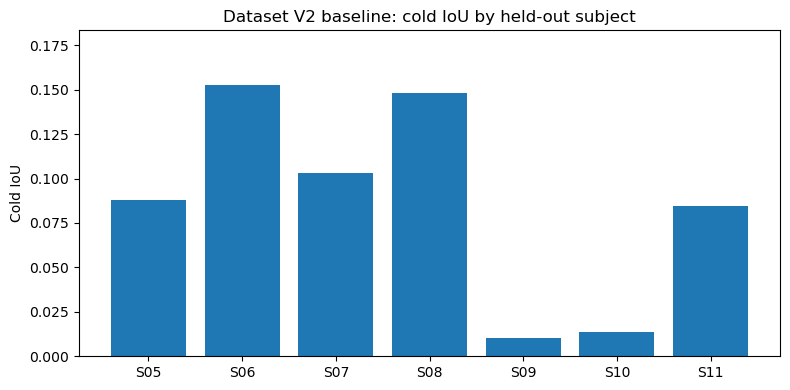

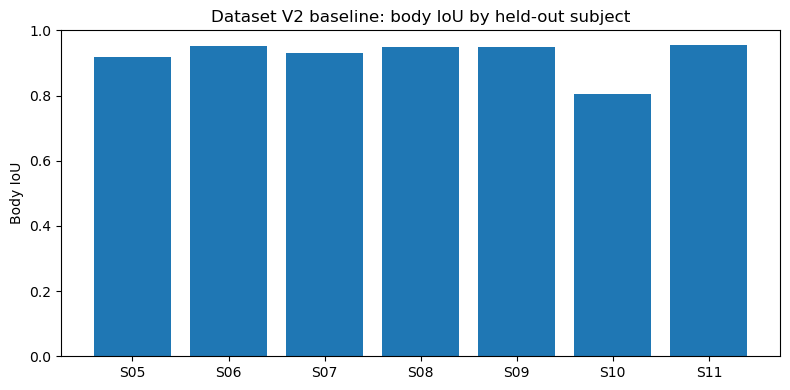

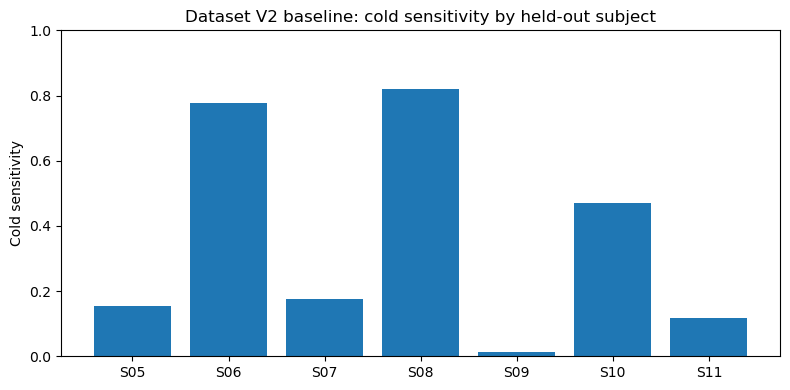

Figures saved to: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/runs_baseline_hierunet_v2_loso/figures


In [21]:
# ============================================================
# SECTION 12 — QUICK RESULT PLOTS
# ============================================================

plot_dir = RUN_ROOT / "figures"
plot_dir.mkdir(parents=True, exist_ok=True)
summary = pd.read_csv(RUN_ROOT / "loso_test_summary.csv")

plt.figure(figsize=(8, 4))
plt.bar(summary["test_subject"], summary["cold_iou"])
plt.ylabel("Cold IoU")
plt.title("Dataset V2 baseline: cold IoU by held-out subject")
plt.ylim(0, max(0.05, float(summary["cold_iou"].max()) * 1.2))
plt.tight_layout()
plt.savefig(plot_dir / "baseline_cold_iou_by_subject.png", dpi=250)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(summary["test_subject"], summary["body_iou"])
plt.ylabel("Body IoU")
plt.title("Dataset V2 baseline: body IoU by held-out subject")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig(plot_dir / "baseline_body_iou_by_subject.png", dpi=250)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(summary["test_subject"], summary["cold_sensitivity"])
plt.ylabel("Cold sensitivity")
plt.title("Dataset V2 baseline: cold sensitivity by held-out subject")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig(plot_dir / "baseline_cold_sensitivity_by_subject.png", dpi=250)
plt.show()

print("Figures saved to:", plot_dir)

## Expected outputs

After running the notebook, send back these files:

- `runs_baseline_hierunet_v2_loso/loso_test_summary.csv`
- `runs_baseline_hierunet_v2_loso/loso_final_mean_std.csv`
- `runs_baseline_hierunet_v2_loso/loso_test_per_case.csv`

Then we will decide whether to move to safe augmentation or modify the baseline model first.